# Titanic Data Preprocessing Handbook
Upload Kaggle Titanic `train.csv` to the same folder.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"drtulasiprasadsariki","key":"71a6d0bfcf7945f14ed00b166b028b6d"}'}

In [3]:
# Create the necessary hidden directory
!mkdir -p ~/.kaggle

# Move the API token into the directory
!cp kaggle.json ~/.kaggle/

# Secure the file permissions so other users cannot read it
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets list

ref                                                             title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset  FIFA World Cup 2026 Player Performance Dataset     4154062  2026-06-10 12:58:47.093000          12543        309                1  
abbas829/ecommerce-sales-dataset                                Ecommerce sales dataset                             110951  2026-07-03 00:59:03.347000           1767         38                1  
ashyou09/global-budget-allocation-dataset-19362026              Global Budget Allocation Dataset (1936–2026) 🌎      295046  2026-07-11 08:11:16.587000            811         29                1  
ashyou09/apple-produ

In [6]:
!kaggle competitions download -c titanic

100% 34.1k/34.1k [00:00<00:00, 45.4MB/s]



In [7]:
!unzip titanic.zip

Archive:  titanic.zip
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [8]:
df=pd.read_csv('/content/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Overview

In [10]:
print(df.shape)

(891, 12)


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [12]:
print(df.describe(include='all'))

        PassengerId    Survived      Pclass                 Name   Sex  \
count    891.000000  891.000000  891.000000                  891   891   
unique          NaN         NaN         NaN                  891     2   
top             NaN         NaN         NaN  Dooley, Mr. Patrick  male   
freq            NaN         NaN         NaN                    1   577   
mean     446.000000    0.383838    2.308642                  NaN   NaN   
std      257.353842    0.486592    0.836071                  NaN   NaN   
min        1.000000    0.000000    1.000000                  NaN   NaN   
25%      223.500000    0.000000    2.000000                  NaN   NaN   
50%      446.000000    0.000000    3.000000                  NaN   NaN   
75%      668.500000    1.000000    3.000000                  NaN   NaN   
max      891.000000    1.000000    3.000000                  NaN   NaN   

               Age       SibSp       Parch  Ticket        Fare Cabin Embarked  
count   714.000000  891.000000 

In [13]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Missing Value Handling

In [14]:
# Mean
df_mean=df.copy()
df_mean['Age']=SimpleImputer(strategy='mean').fit_transform(df_mean[['Age']])

In [17]:
print(df_mean.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [18]:
# Median
df_median=df.copy()
df_median['Age']=SimpleImputer(strategy='median').fit_transform(df_median[['Age']])

In [19]:
# Mode
df_mode=df.copy()
df_mode['Embarked']=SimpleImputer(strategy='most_frequent').fit_transform(df_mode[['Embarked']]).ravel()

In [20]:
print(df_mode.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [21]:
# Constant
df_const=df.copy()
df_const['Cabin']=df_const['Cabin'].fillna('Unknown')

In [23]:
print(df_const.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin            0
Embarked         2
dtype: int64


In [24]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [26]:
# KNN
df_knn=df.copy()
df_knn['Sex']=LabelEncoder().fit_transform(df_knn['Sex'])
df_knn['Embarked']=df_knn['Embarked'].fillna(df_knn['Embarked'].mode()[0])
df_knn['Embarked']=LabelEncoder().fit_transform(df_knn['Embarked'])
df_knn[['Age','Fare']]=KNNImputer().fit_transform(df_knn[['Age','Fare']])

In [27]:
print(df_knn.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


## Encoding

In [29]:
enc=df.copy()
enc['Sex_Label']=LabelEncoder().fit_transform(enc['Sex'])
onehot=pd.get_dummies(enc,columns=['Embarked'],drop_first=True)
onehot.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_Label,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,1,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,0,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,1,False,True


## Scaling

In [32]:
X=df[['Age','Fare']].copy()
X['Age']=X['Age'].fillna(X['Age'].median())

In [33]:
print(MinMaxScaler().fit_transform(X)[:5])

[[0.27117366 0.01415106]
 [0.4722292  0.13913574]
 [0.32143755 0.01546857]
 [0.43453129 0.1036443 ]
 [0.43453129 0.01571255]]


In [34]:
print(StandardScaler().fit_transform(X)[:5])

[[-0.56573646 -0.50244517]
 [ 0.66386103  0.78684529]
 [-0.25833709 -0.48885426]
 [ 0.4333115   0.42073024]
 [ 0.4333115  -0.48633742]]


In [35]:
print(RobustScaler().fit_transform(X)[:5])

[[-0.46153846 -0.3120106 ]
 [ 0.76923077  2.46124229]
 [-0.15384615 -0.28277666]
 [ 0.53846154  1.6737319 ]
 [ 0.53846154 -0.27736297]]


## Outlier Detection

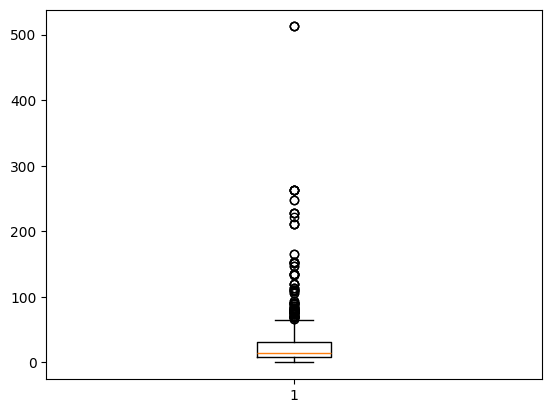

Outliers: 179


In [36]:
plt.boxplot(df['Fare'].dropna())
plt.show()

iso=IsolationForest(random_state=42)
pred=iso.fit_predict(df[['Fare']].fillna(df['Fare'].median()))
print('Outliers:',(pred==-1).sum())

## Feature Engineering

In [37]:
fe=df.copy()
fe['FamilySize']=fe['SibSp']+fe['Parch']+1
fe['IsAlone']=(fe['FamilySize']==1).astype(int)
fe['Title']=fe['Name'].str.extract(' ([A-Za-z]+)\.',expand=False)
fe[['FamilySize','IsAlone','Title']].head()

<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_913/1558264905.py:4: SyntaxWarning: invalid escape sequence '\.'
  fe['Title']=fe['Name'].str.extract(' ([A-Za-z]+)\.',expand=False)


,FamilySize,IsAlone,Title
0,2,0,Mr
1,2,0,Mrs
2,1,1,Miss
3,2,0,Mrs
4,1,1,Mr


## Feature Selection

In [38]:
fs=fe.copy()
fs['Sex']=LabelEncoder().fit_transform(fs['Sex'])
fs['Embarked']=fs['Embarked'].fillna(fs['Embarked'].mode()[0])
fs['Embarked']=LabelEncoder().fit_transform(fs['Embarked'])
fs['Age']=fs['Age'].fillna(fs['Age'].median())
X=fs[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
y=fs['Survived']
print(VarianceThreshold().fit_transform(X).shape)
print(SelectKBest(score_func=chi2,k=4).fit(X,y).scores_)

(891, 7)
[3.08736994e+01 9.27024470e+01 2.16491630e+01 2.58186538e+00
 1.00974991e+01 4.51831909e+03 1.02025247e+01]


## PCA

In [39]:
Xs=StandardScaler().fit_transform(X)
pca=PCA(n_components=2)
Xp=pca.fit_transform(Xs)
print(pca.explained_variance_ratio_)

[0.26512593 0.24494388]


## Train/Test Split

In [40]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape,X_test.shape)

(712, 7) (179, 7)
